In [3]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
class ID3TreeNode:
    def __init__(self):
        self.feature = None      
        self.threshold = None    
        self.left = None         
        self.right = None        
        self.predicted_class = None 


class ID3DecisionTree:

    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def entropy(self, Y):
        if len(Y) == 0:
            return 0.0
        _, counts = np.unique(Y, return_counts=True)
        probs = counts / len(Y)
        return -np.sum(probs * np.log2(probs))

    def information_gain(self, Y, Y_left, Y_right):
        
        n = len(Y)
        weighted_child_entropy = (len(Y_left) / n) * self.entropy(Y_left) + (len(Y_right) / n) * self.entropy(Y_right)
        return self.entropy(Y) - weighted_child_entropy

    def best_split(self, X, Y):
        best_feature, best_threshold, best_gain = None, None, -float('inf')
        n_features = X.shape[1]
        parent_entropy = self.entropy(Y)

        for feature in range(n_features):
            values = np.unique(X[:, feature])

            for i in range(len(values) - 1):
                threshold = (values[i] + values[i + 1]) / 2
                mask = X[:, feature] <= threshold

                Y_left, Y_right = Y[mask], Y[~mask]
                if len(Y_left) == 0 or len(Y_right) == 0:
                    continue

                gain = parent_entropy - ((len(Y_left) / len(Y)) * self.entropy(Y_left) + (len(Y_right) / len(Y)) * self.entropy(Y_right))
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def build_tree(self, X, Y, depth):
        node = ID3TreeNode()
        
        if len(np.unique(Y)) == 1 or len(Y) < self.min_samples_split or (self.max_depth is not None and depth >= self.max_depth):
            node.predicted_class = np.bincount(Y).argmax()
            return node

        feature, threshold = self.best_split(X, Y)

        if feature is None:
            node.predicted_class = np.bincount(Y).argmax()
            return node

        mask = X[:, feature] <= threshold

        node.feature = feature
        node.threshold = threshold
        node.left = self.build_tree(X[mask], Y[mask], depth + 1)
        node.right = self.build_tree(X[~mask], Y[~mask], depth + 1)

        return node


    def display(self, node=None, depth=0, feature_names=None):
        if node is None:
            node = self.root
        indent = '  ' * depth
        if node.predicted_class is not None:
            print(f"{indent}-> class {node.predicted_class}")
        else:
            name = feature_names[node.feature] if feature_names else f"X[{node.feature}]"
            print(f"{indent}{name} <= {node.threshold:.2f}")
            self.display(node.left, depth + 1, feature_names)
            self.display(node.right, depth + 1, feature_names)

    def fit(self, X, Y):
        self.root = self.build_tree(np.array(X), np.array(Y), depth=0)
        return self

    def predict_sample(self, x, node):
        if node.predicted_class is not None:
            return node.predicted_class
        if x[node.feature] <= node.threshold:
            return self.predict_sample(x, node.left)
        return self.predict_sample(x, node.right)

    def predict(self, X):
        return np.array([self.predict_sample(x, self.root) for x in X])

In [5]:
dataset = pd.read_csv('/Users/pranesh/coding2/MachineLearningFrom0/datasets/Iris.csv')
dataset.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
dataset.shape

(150, 6)

In [7]:
dataset['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [8]:
from sklearn.preprocessing import LabelEncoder

X = dataset[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']].values
Y = LabelEncoder().fit_transform(dataset['Species'].values)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f'Training samples: {len(X_train)}')
print(f'Test samples:     {len(X_test)}')

Training samples: 120
Test samples:     30


In [9]:
model = ID3DecisionTree(max_depth=5)
model.fit(X_train, Y_train)

In [10]:
feature_names = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
model.display(feature_names=feature_names)

PetalLengthCm <= 2.45
  -> class 0
  PetalLengthCm <= 4.75
    PetalWidthCm <= 1.65
      -> class 1
      -> class 2
    PetalWidthCm <= 1.75
      PetalLengthCm <= 4.95
        -> class 1
        PetalWidthCm <= 1.55
          -> class 2
          -> class 1
      PetalLengthCm <= 4.85
        SepalLengthCm <= 5.95
          -> class 1
          -> class 2
        -> class 2


In [11]:
Y_pred = model.predict(X_test)
print(Y_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [12]:
accuracy = accuracy_score(Y_test, Y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 1.0000


In [13]:
confusion_matrix(Y_test, Y_pred)

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

In [14]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [15]:
from sklearn.tree import DecisionTreeClassifier as SklearnDecisionTree

sklearn_model = SklearnDecisionTree(criterion='entropy', max_depth=5, random_state=42)
sklearn_model.fit(X_train, Y_train)

sklearn_pred = sklearn_model.predict(X_test)

print(f'sklearn accuracy:     {accuracy_score(Y_test, sklearn_pred):.4f}')
print(f'from-scratch accuracy: {accuracy:.4f}')

sklearn accuracy:     1.0000
from-scratch accuracy: 1.0000


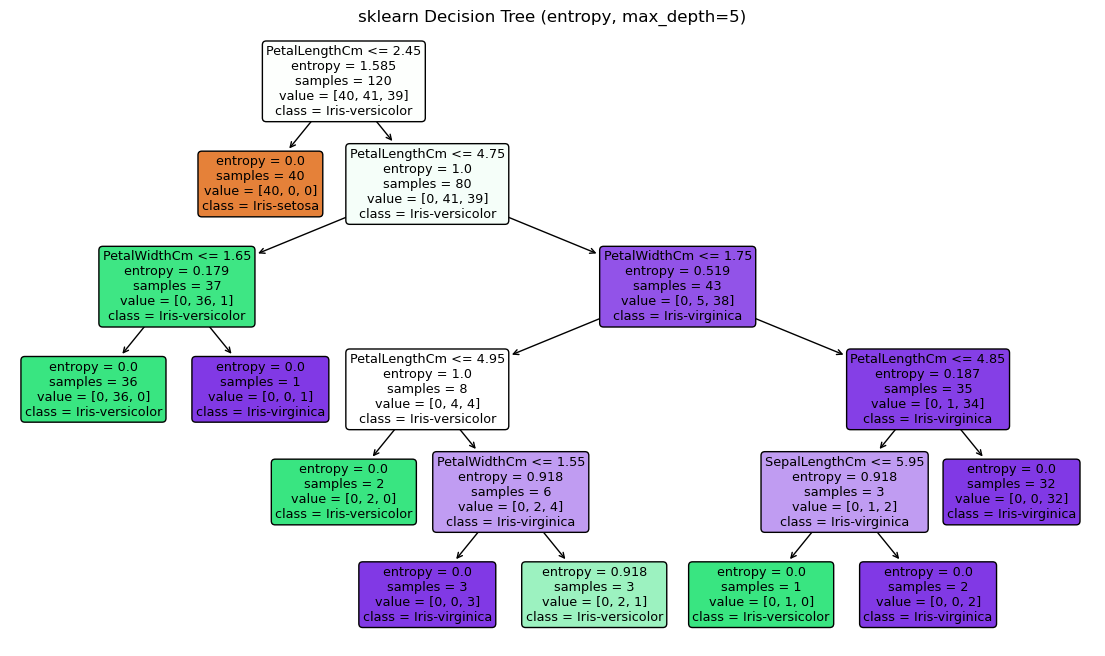

In [16]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(14, 8))
plot_tree(sklearn_model,
          feature_names=feature_names,
          class_names=dataset['Species'].unique(),
          filled=True,
          rounded=True)
plt.title('sklearn Decision Tree (entropy, max_depth=5)')
plt.show()